# Network Graph
### In Networkx, a graph is essentially nodes and edges.
Nodes: It is a location or a point in a network
 - In this project, the nodes are substaions
Edges: It is a connection between two nodes
 - In this project, the edges are transmission lines

 We have 44 nodes connected by 55 edges

 ### Networkx Graph Types
 #### There are four types; 
 1. directed graph, 
 2. undirected graph. 
 3. multidirected graph and 
 4. multiundirected graph.
 - In this project, we will use undirected graph because AC (Alternating power) can flow in either direction along
 a line depending on the system conditions. 
 - Thus, we just need a connection, not a direction.

In [91]:
%pip install networkx


Note: you may need to restart the kernel to use updated packages.


In [92]:
# Importing Networkx

import networkx as nx 
import matplotlib.pyplot as plt 

G = nx.Graph()

print(G.number_of_nodes())    # 0 , since no nodes have being added
print(G.number_of_edges())   

0
0


In [93]:
#   Loading the substations dataset
import pandas as pd 
from pathlib import Path

substations = pd.read_csv("../../data/raw/substations.csv")
substations.head(3)

,Substation ID,Name,Short Name,Region,Country,Latitude,Longitude,Voltage (kV),Capacity (MVA),Commissioning Year,Type,Status
0,1,Achimota Substation,Achimota,Greater Accra,Ghana,5.6085,-0.2193,11,6.4,2008,Distribution,Active
1,2,Tema Substation,Tema,Greater Accra,Ghana,5.6596,-0.0226,330,48.5,1997,Transmission,Active
2,3,Mallam Substation,Mallam,Greater Accra,Ghana,5.5630,-0.2971,330,25.2,1979,Transmission,Active


In [94]:
# Adding the nodes to the networkx graph

G.add_nodes_from(substations['Substation ID'])
print(f" Number of nodes: {G.number_of_nodes()}")    
print(f" Number of edges: {G.number_of_edges()}")   # still 0, since no edges exist now

 Number of nodes: 44
 Number of edges: 0


In [95]:
# processed_data is same as the lines_complete dataset

lines_complete = pd.read_csv("processed_data.csv", index_col=0)
lines_complete.head(3)
# print(lines_complete.columns)

,Utility ID,Source Substation ID,Source Substation,Destination Substation ID,Destination Substation,Line Voltage (kV),Line Length (km),Line Capacity (MVA),Line Status,Line Type,...,Destination Short Name,Destination Region,Destination Country,Destination Latitude,Destination Longitude,Destination Voltage (kV),Destination Capacity (MVA),Destination Commissioning Year,Destination Type,Destination Status
Line ID,,,,,,,,,,,,,,,,,,,,,
1,2,1,Achimota Substation,2,Tema Substation,11,25.2,215.0,Active,Underground,...,Tema,Greater Accra,Ghana,5.6596,-0.0226,330,48.5,1997,Transmission,Active
2,2,1,Achimota Substation,3,Mallam Substation,11,11.0,36.4,Active,Overhead,...,Mallam,Greater Accra,Ghana,5.5630,-0.2971,330,25.2,1979,Transmission,Active
3,3,1,Achimota Substation,5,Kaneshie Substation,11,5.9,277.4,Active,Overhead,...,Kaneshie,Greater Accra,Ghana,5.5691,-0.2413,161,146.0,1970,Transmission,Active


In [96]:
# Adding edges or forming edges between source node and destination node
'''
Go through each row in the processed_data ( lines_complete dataset), for each row
add an edge between the source substation id and the destination substations id
'''
for _,row in lines_complete.iterrows():
    G.add_edge(
        row['Source Substation ID'],
        row['Destination Substation ID']
        )

print(f" Number of nodes: {G.number_of_nodes()}")    
print(f" Number of edges: {G.number_of_edges()}")

 Number of nodes: 44
 Number of edges: 55


In [97]:
set(G.nodes) - set(substations['Substation ID'])

set()

In [98]:
# Adding specific attributes of each node( or substation) to the networkx

for _, row in substations.iterrows():
    G.nodes[row["Substation ID"]]["Name"] = row['Name']
    G.nodes[row["Substation ID"]]["Region"] = row["Region"]
    G.nodes[row["Substation ID"]]["Voltage"] = row["Voltage (kV)"]
    G.nodes[row["Substation ID"]]["Capacity"] = row["Capacity (MVA)"]
    G.nodes[row["Substation ID"]]["Coordinate"] = row[["Latitude","Longitude"]]

#  inspecting random nodes to verify if attrinutes has ben added     
print(G.nodes[9])
print(G.nodes[23])

# Inspect all nodes
# G.nodes(data=True)

{'Name': 'Obuasi Substation', 'Region': 'Ashanti', 'Voltage': 33, 'Capacity': 47.5, 'Coordinate': Latitude     6.2091
Longitude   -1.6557
Name: 8, dtype: object}
{'Name': 'Suhum Substation', 'Region': 'Eastern', 'Voltage': 69, 'Capacity': 339.0, 'Coordinate': Latitude      6.035
Longitude   -0.4535
Name: 22, dtype: object}


In [99]:
print(G.edges)
# Adding specific attributes to the edges( transmission lines)

for _,row in lines_complete.iterrows():
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Length"] = row['Line Length (km)']
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Voltage"] = row['Line Voltage (kV)']
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Capacity"] = row['Line Capacity (MVA)']
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Status"] = row['Line Status']
    G.edges[row["Source Substation ID"],row["Destination Substation ID"]]["Type"] = row['Line Type']

#  inspecting random edges to verify if attributes has ben added 
print(G.edges[1,2])
print(G.edges[7,10])

# inspect all edges
G.edges(data=True)


[(1, 2), (1, 3), (1, 5), (1, 7), (2, 3), (2, 4), (2, 39), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (7, 10), (7, 11), (7, 12), (7, 38), (8, 9), (8, 11), (9, 11), (10, 11), (12, 13), (12, 14), (12, 16), (13, 14), (13, 15), (14, 15), (16, 17), (16, 18), (16, 19), (16, 20), (17, 18), (18, 19), (20, 21), (20, 22), (20, 24), (21, 22), (21, 23), (22, 23), (24, 25), (24, 27), (24, 28), (25, 27), (26, 27), (28, 29), (28, 31), (29, 30), (31, 32), (31, 34), (34, 35), (34, 36), (34, 37), (37, 43), (38, 42), (39, 40), (40, 41)]
{'Length': 25.2, 'Voltage': 11, 'Capacity': 215.0, 'Status': 'Active', 'Type': 'Underground'}
{'Length': 53.3, 'Voltage': 69, 'Capacity': 269.1, 'Status': 'Active', 'Type': 'Overhead'}


EdgeDataView([(1, 2, {'Length': 25.2, 'Voltage': 11, 'Capacity': 215.0, 'Status': 'Active', 'Type': 'Underground'}), (1, 3, {'Length': 11.0, 'Voltage': 11, 'Capacity': 36.4, 'Status': 'Active', 'Type': 'Overhead'}), (1, 5, {'Length': 5.9, 'Voltage': 11, 'Capacity': 277.4, 'Status': 'Active', 'Type': 'Overhead'}), (1, 7, {'Length': 225.4, 'Voltage': 330, 'Capacity': 303.7, 'Status': 'Active', 'Type': 'Overhead'}), (2, 3, {'Length': 34.4, 'Voltage': 330, 'Capacity': 39.0, 'Status': 'Active', 'Type': 'Underground'}), (2, 4, {'Length': 19.5, 'Voltage': 161, 'Capacity': 186.5, 'Status': 'Active', 'Type': 'Underground'}), (2, 39, {'Length': 157.9, 'Voltage': 330, 'Capacity': 207.8, 'Status': 'Active', 'Type': 'Overhead'}), (3, 4, {'Length': 17.1, 'Voltage': 161, 'Capacity': 220.5, 'Status': 'Active', 'Type': 'Underground'}), (3, 5, {'Length': 7.0, 'Voltage': 161, 'Capacity': 108.5, 'Status': 'Active', 'Type': 'Overhead'}), (3, 6, {'Length': 22.4, 'Voltage': 161, 'Capacity': 298.9, 'Status': 

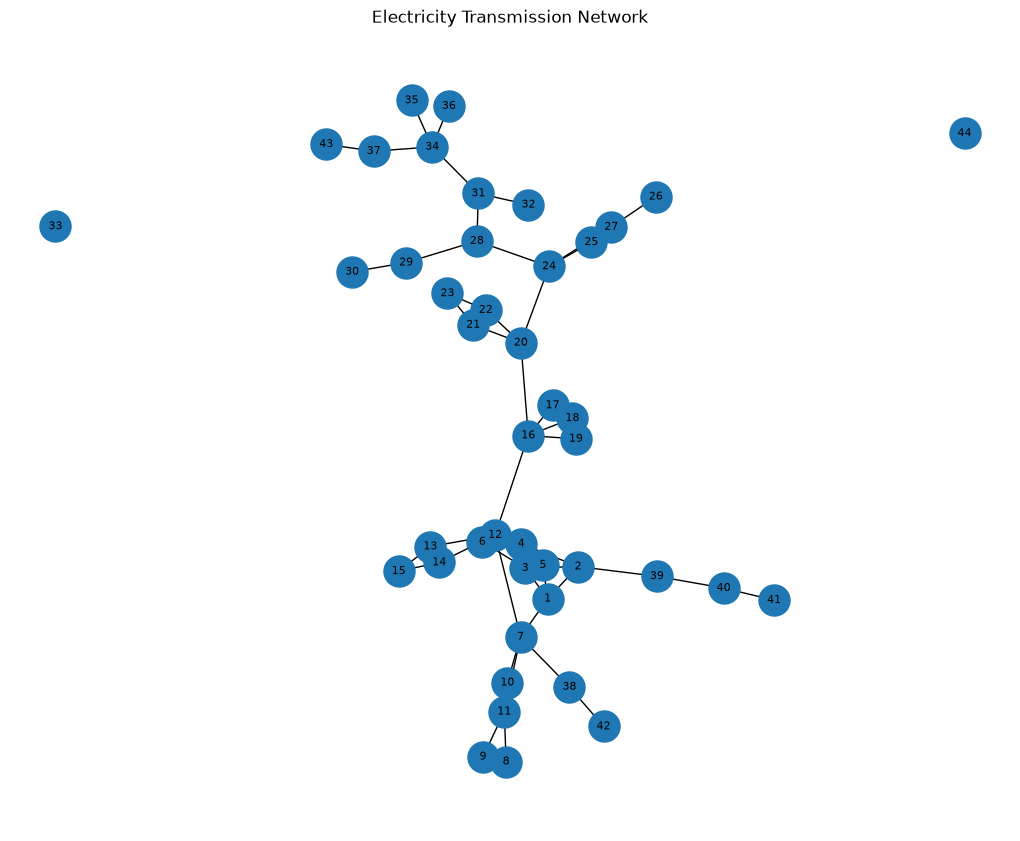

In [100]:
# Visualizing the graph

plt.figure(figsize=(10,8))     # controls the size of the graph interface making it clear

# Creating artificial positions of the nodes based on how they are connected 
positions = nx.spring_layout(G, seed=42)

# Drawing the network using the positions

nx.draw(G,                     # graph built
positions,                     # coordinates of the nodes
with_labels= True,             # shows the substations or nodes by their label
node_size= 500,                # makes the nodes big and visible
font_size= 8)                  # controls the fontsize of the label

plt.title('Electricity Transmission Network')
plt.show()

The network visualization shows that most substations form a connected structure, while nodes 33 and 44 appear isolated with no visible transmission-line connection

## Calculations of Network Metric
### Degree
 - Degree is the number of transmission lines connected directly to a node or substation.
 - Used .degree() method
 

In [101]:
degree = dict(G.degree())
sorted_degree = sorted(degree.items(), key=lambda x: x[1], reverse=True)
print(sorted_degree)

[(3, 5), (7, 5), (16, 5), (1, 4), (2, 4), (4, 4), (11, 4), (12, 4), (20, 4), (24, 4), (34, 4), (5, 3), (13, 3), (14, 3), (18, 3), (21, 3), (22, 3), (27, 3), (28, 3), (31, 3), (6, 2), (8, 2), (9, 2), (10, 2), (15, 2), (17, 2), (19, 2), (23, 2), (25, 2), (29, 2), (37, 2), (38, 2), (39, 2), (40, 2), (26, 1), (30, 1), (32, 1), (35, 1), (36, 1), (41, 1), (42, 1), (43, 1), (33, 0), (44, 0)]


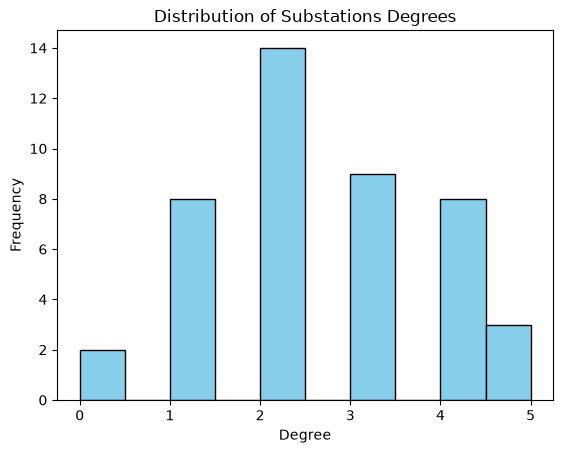

In [102]:
# Distribution of the degree of the nodes
import statistics
import matplotlib.pyplot as plt
degree_values = list(degree.values())

plt.hist(degree_values, color='skyblue', edgecolor='black')
plt.title('Distribution of Substations Degrees')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

The degree analysis shows three substations, Substation 3, 7 and 16 have the highest direct connections with 5 transmission lines of connection and Substation 33 and 44 are isolated substations with no connection. Also, it appears that the most common degree among the substations is 2, thus most have two direct tramsmission line connections.

### Degree Centrality
 - It is normalises the degree relative to the number to the nodes in the network structure
 - It is expressed on a standard scale of 0  - 1 or 0% - 100%
 - CD(node) = degree(node) / n -1 , where n = total nodes in the network.
 - 0 <= CD <= 1
 - used nx.degree_centrality(G)
 

In [103]:
degree_centrality = nx.degree_centrality(G)
# print(degree_centrality)  gives a dictionary of key-value pairs.

sorted_degree_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
print(sorted_degree_centrality)

print(f"{sorted_degree_centrality[0][1]:.1%}")
print(f"Average degree centrality: {statistics.mean(degree_centrality.values()):.1%}")

[(3, 0.11627906976744186), (7, 0.11627906976744186), (16, 0.11627906976744186), (1, 0.09302325581395349), (2, 0.09302325581395349), (4, 0.09302325581395349), (11, 0.09302325581395349), (12, 0.09302325581395349), (20, 0.09302325581395349), (24, 0.09302325581395349), (34, 0.09302325581395349), (5, 0.06976744186046512), (13, 0.06976744186046512), (14, 0.06976744186046512), (18, 0.06976744186046512), (21, 0.06976744186046512), (22, 0.06976744186046512), (27, 0.06976744186046512), (28, 0.06976744186046512), (31, 0.06976744186046512), (6, 0.046511627906976744), (8, 0.046511627906976744), (9, 0.046511627906976744), (10, 0.046511627906976744), (15, 0.046511627906976744), (17, 0.046511627906976744), (19, 0.046511627906976744), (23, 0.046511627906976744), (25, 0.046511627906976744), (29, 0.046511627906976744), (37, 0.046511627906976744), (38, 0.046511627906976744), (39, 0.046511627906976744), (40, 0.046511627906976744), (26, 0.023255813953488372), (30, 0.023255813953488372), (32, 0.0232558139534

 - The 5.8% average degree centrality means on average, a substation has direct connections to about 5.8% of the other substations in the network that it could potentially connect to.

### Betweenness Centrality
 - This is the measure of how often a node(substation) lies on the shortest path between two other nodes oe substations. 
 - This helps us to identify which substations act as connectors and which ones are bottlenecks. In such a way that without their presence, the elctricity flow is disrupted.
 - Used nx.betweenness_centrality(G)

In [104]:
betweenness = nx.betweenness_centrality(G)
print(f"Betweenness Centrality: {betweenness}")

sorted_betweenness = sorted(betweenness.items(), key= lambda x:x[1], reverse=True)
print(f"Sorted Betweenness Centrality: {sorted_betweenness}")
highest_betweeness = {key:value for key,value in betweenness.items() if value == max(betweenness.values())}
print(f"substation with highest betweenness: {highest_betweeness}")

Betweenness Centrality: {1: 0.29383536360280543, 2: 0.13879660391288295, 3: 0.054448135843484624, 4: 0.004245108896271686, 5: 0.012550756736803238, 6: 0.0, 7: 0.5005537098560354, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.08637873754152824, 12: 0.5160575858250277, 13: 0.02159468438538206, 14: 0.02159468438538206, 15: 0.0, 16: 0.5254706533776301, 17: 0.0, 18: 0.0005537098560354374, 19: 0.0, 20: 0.4983388704318937, 21: 0.02159468438538206, 22: 0.02159468438538206, 23: 0.0, 24: 0.4363233665559247, 25: 0.0, 26: 0.0, 27: 0.04429678848283499, 28: 0.3344407530454042, 29: 0.04429678848283499, 30: 0.0, 31: 0.23809523809523808, 32: 0.0, 33: 0.0, 34: 0.16943521594684385, 35: 0.0, 36: 0.0, 37: 0.04429678848283499, 38: 0.04429678848283499, 39: 0.08637873754152824, 40: 0.04429678848283499, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0}
Sorted Betweenness Centrality: [(16, 0.5254706533776301), (12, 0.5160575858250277), (7, 0.5005537098560354), (20, 0.4983388704318937), (24, 0.4363233665559247), (28, 0.3344407530454042), (1

- This shows that substation 16 frequently lies on the shortest path connecting other substations, this indicates that substation 16 has a very strong intermediary or connecting role in the network making it have high structurally importance.
- Because node 16 has the highest betweenness centrality, its failure could disrupt or force alternative, potentially longer routes between some substations.

- Some substations have 0 betweenness, this doesn't mean they are not importance, rather they do not act as connectors (does not lie on any shortest path between other nodes) but are important to the customers they serve. 


## Closeness Centrality
- It is the measure of how close a substation is to the other substations in the network.
- It is different from betweenness centrality, betweeness centrality is the measure of how often other nodes/substations need to pass through a node whilst closeness centrality is the measure of how quickly a node can reach other nodes/ substations in the network.

-  A substation with the highest closeness centrality is relatively well positioned in the network structure. Therefore Higher closeness implies Good network reachability
 
- Formula; Cc(v) = n -1 / Summation[d(v,u)], v != u
where; n= number of nodes
    d(v,u) = is the shortest path distance between node v and node u 
- used nx.closeness_centrality(G)
- Therefore, a node with shortest total distance implies higher closeness implies good network reachability

- A node in a component cannot connect an isolated node.
- Use the nx.number_connected_components(G) to get number of connected nodes
- Connected component is a group of nodes in which every node can reach every other node through some path.



In [105]:
print(f"Number of Connected Components: {nx.number_connected_components(G)}")

Number of Connected Components: 3


The network contains three connected components, indicating that the transmission network represented in the dataset is not fully connected. This means some substations or groups of substations cannot be reached from other groups through the transmission lines represented in the graph. And this can be seen through the Graph, there are three components;
 1. main components
 2. 33 isolated node
 3. 44 isolated node

 

In [106]:
closeness = nx.closeness_centrality(G)
print(f"closeness Centrality: {closeness}")

sorted_closeness = sorted(closeness.items(), key=lambda x:x[1], reverse=True)
print(f"Sorted Closeness Centrality: {sorted_closeness}")

highest_closeness = {key:value for key,value in closeness.items() if value == max(closeness.values())}
print(f"substation with the short shortest path distance: {highest_closeness}")

closeness Centrality: {1: 0.21246208291203236, 2: 0.18267767876548577, 3: 0.18182801514332073, 4: 0.15700009339684318, 5: 0.1776955602536998, 6: 0.1539095403772203, 7: 0.2443313953488372, 8: 0.16706420194792287, 9: 0.16706420194792287, 10: 0.19844174241529927, 11: 0.20047704233750746, 12: 0.2606201550387597, 13: 0.20905360029847034, 14: 0.20905360029847034, 15: 0.17297797900802636, 16: 0.26414204902577, 17: 0.20905360029847034, 18: 0.21017754438609654, 19: 0.20905360029847034, 20: 0.25385080036242824, 21: 0.2046755144283453, 22: 0.2046755144283453, 23: 0.1699696663296259, 24: 0.23269656699889257, 25: 0.18977195755249493, 26: 0.15956336022781206, 27: 0.19069767441860466, 28: 0.2057527539779682, 29: 0.1714606283149735, 30: 0.14586948976049982, 31: 0.17932579475144017, 32: 0.15152334595276726, 33: 0.0, 34: 0.15637209302325583, 35: 0.134803528468324, 36: 0.134803528468324, 37: 0.13573966408268734, 38: 0.19743951139299978, 39: 0.15637209302325583, 40: 0.13573966408268734, 41: 0.119186046511

This results shows that Node 16 or Substation 16 has relatively the shortest total distance with other substations within its reachable network.
This also validate the structural importance of substation 16 to the other substations in the network

## PageRank
 - It is the measure of the importance of a substation or node based on the importance of substations it is connected to.
 - It answers the question, who are connected to and how important are those connections.
 - Assuming node B connects A,C, and D and all these three nodes have high important since node B had direct connection with them it will receive a stronger PageRank score.
 - Sum of all PageRank score od the nodes must be 1
 - PageRank score depends on;
  1. Who connects to you
  2. How important those nodes are
  3. How many other nodes are those nodes also connected to
 
 - Used nx.pagerank(G), gives result as key-value pair relationship(dictionary)
 


In [107]:
# Installing Scipy module since Networkx uses Scipy to calculate PageRank
%pip install Scipy

Note: you may need to restart the kernel to use updated packages.


In [108]:
pagerank = nx.pagerank(G)
print(f"PageRank Scores: {pagerank}")

sorted_pagerank = sorted(pagerank.items(), key=lambda x:x[1], reverse=True)
print(f"Sorted PageRank Scores: {sorted_pagerank}")

highest_pagerank_score = {key:value for key, value in pagerank.items() if value == max(pagerank.values())}
print(f"Substation with high PageRank Score: {highest_pagerank_score}")

print(f"Total PageRank Score: {sum(pagerank.values()):.2f}")

PageRank Scores: {1: 0.028714704133771744, 2: 0.030149294547150637, 3: 0.034893161084669326, 4: 0.028637681574222022, 5: 0.021665195730248853, 6: 0.015563365589501017, 7: 0.0393616304916822, 8: 0.018472697370557557, 9: 0.018472697370557557, 10: 0.017313284527098804, 11: 0.033297491167283554, 12: 0.030412730798574067, 13: 0.02420132784050242, 14: 0.02420132784050242, 15: 0.017260130134221372, 16: 0.03800694140876495, 17: 0.01691664868005698, 18: 0.024386333113945485, 19: 0.01691664868005698, 20: 0.031574277585548385, 21: 0.024720210599844902, 22: 0.024720210599844902, 23: 0.01755409218555215, 24: 0.035573536857529224, 25: 0.01946186547601878, 26: 0.011902802186983483, 27: 0.029493844338046915, 28: 0.03066612382000631, 29: 0.023875109787359558, 30: 0.013692087641746625, 31: 0.03323429636775252, 32: 0.012961072180004531, 33: 0.0035460992907801426, 34: 0.04695543286047507, 35: 0.01352610290384411, 36: 0.01352610290384411, 37: 0.025895601820117877, 38: 0.02074637520522674, 39: 0.01996320244

- Degree(34) = 4  but PageRank(34) = 0.04696
- Degree(16) = 5  but PageRank(16) = 0.03801
- So having the many cooncetions does not automatically give you a higher pagerank score.

- From previous analysis, Substation 16 demonstrates strong structural importance across several network metrics, it has the highest betweenness and closeness centrality and tied with node 3 and 7 for the highest degree. However, node 34 has the highest PageRank, this shows that different centrality measures identify different forms of network importance.So one metric cannot be used to check nodes importance in the whole network structure. 

